In [1]:
import os
import requests

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({'axes.titlesize': 'small'})

import torch
import torch.nn.functional as F

import torchvision
from torchvision.utils import make_grid

import numpy as np

from torchvision import transforms

print(f"GPU: {torch.cuda.is_available()}")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

GPU: True
cuda


In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path
from tqdm import tqdm
import cv2

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({'axes.titlesize': 'small'})

import json

def hex2rgb(col_hex: str):
    col_hex = col_hex.lstrip("#")
    return tuple(int(col_hex[i:i+2], 16) for i in (0, 2, 4))

def rgb2hex(r, g, b):
    return '#{:02x}{:02x}{:02x}'.format(r, g, b)



def display_image(image_tensor):
    """
    Отображает изображение, представленное в виде тензора numpy, с помощью matplotlib.

    :param image_tensor: Тензор numpy, представляющий изображение
    """
    try:
        # Проверяем, что входные данные являются массивом numpy
        if not isinstance(image_tensor, np.ndarray):
            raise ValueError("Входные данные должны быть тензором numpy.")
        
        # Определяем, является ли изображение черно-белым или цветным
        if len(image_tensor.shape) == 2:  # Черно-белое изображение
            plt.imshow(image_tensor, cmap='gray')
        elif len(image_tensor.shape) == 3:  # Цветное изображение
            plt.imshow(image_tensor)
        else:
            raise ValueError("Неподдерживаемый формат изображения.")
        
        # Отключаем оси для удобства
        plt.axis('off')
        
        # Отображаем изображение
        plt.show()
    except Exception as e:
        print(f"Ошибка при отображении изображения: {e}")

def get_classes_from_meta(json_path):
    try:
        # Открываем и читаем JSON-файл
        with open(json_path, 'r', encoding='utf-8') as file:
            root = json.load(file)
        
        # Проверяем, есть ли ключ "classes" в "root"
        if "classes" not in root:
            raise KeyError("Ключ 'classes' отсутствует в 'root'.")
        
        # Проходим по массиву "classes"
        classes = root["classes"]
        if not isinstance(classes, list):
            raise TypeError("'classes' должен быть массивом (списком).")
        
        # Обрабатываем каждый элемент в "classes"
        class_color_map = set() # color: classs name
        
        for cls in classes:
            class_color_map.add(hex2rgb(cls['color']))
        return class_color_map
            
    except FileNotFoundError:
        print(f"Файл {json_path} не найден.")
    except json.JSONDecodeError:
        print(f"Ошибка при парсинге JSON-файла {json_path}.")
    except KeyError as e:
        print(f"Ошибка: {e}")
    except TypeError as e:
        print(f"Ошибка: {e}")
    except Exception as e:
        print(f"Произошла непредвиденная ошибка: {e}")


class Dataset(Dataset):
    def __init__(self, root_dir, path_to_meta, transform=None):
        self.root_dir = root_dir
        self.meta_classes = get_classes_from_meta(path_to_meta)
        self.transform = transform
        car_path = Path(f"{root_dir}/cars")
        mask_path = Path(f"{root_dir}/masks")

        self.car_images = []
        self.mask_images = []
        
        self.car_images.extend([p.name for p in list(car_path.glob("*.png"))])
        self.mask_images.extend([p.name for p in list(mask_path.glob("*.png"))])

        self.car_images.extend([p.name for p in list(car_path.glob("*.jpg"))])
        self.mask_images.extend([p.name for p in list(mask_path.glob("*.jpg"))])

        self.car_images.extend([p.name for p in list(car_path.glob("*.jpeg"))])
        self.mask_images.extend([p.name for p in list(mask_path.glob("*.jpeg"))])

        self.car_images = sorted(self.car_images)
        self.mask_images = sorted(self.mask_images)

    def _resize_and_pad(self, image, mask):
        h, w = image.shape[:2]
        max_size = 512
        
        # Вычисляем новые размеры с сохранением пропорций
        if h > w:
            new_h = max_size
            new_w = int(w * max_size / h)
        else:
            new_w = max_size
            new_h = int(h * max_size / w)
        
        # Изменяем размер с разными интерполяциями
        image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LANCZOS4)
        mask = cv2.resize(mask, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
        
        # Создаем новые изображения с черным фоном
        padded_image = np.zeros((max_size, max_size, 3), dtype=image.dtype)
        padded_mask = np.zeros((max_size, max_size, 3), dtype=mask.dtype)
        
        # Вычисляем позиции для вставки
        top = (max_size - new_h) // 2
        left = (max_size - new_w) // 2
        
        # Вставляем изображения в центр
        padded_image[top:top+new_h, left:left+new_w] = image
        padded_mask[top:top+new_h, left:left+new_w] = mask
        
        return padded_image, padded_mask

    def split_segmentation_masks(self, mask, classes):
        """
        Разделяет трёхканальные изображения (маски сегментации) на бинарные маски по классам.
    
        :param batch: NumPy массив формы (3, H, W), где
                      H - высота изображения,
                      W - ширина изображения,
                      3 - три канала (RGB).
        :return: NumPy массив формы (N, C, H, W), где C - количество уникальных классов (цветов),
                 а каждый канал содержит бинарную маску для соответствующего класса.
        """
        # Определяем уникальные цвета во всём батче
        
        # Преобразуем в массив
        num_classes = len(classes)
    
        # Создаем пустой массив для бинарных масок
        print(mask.shape)
        H, W, _  = mask.shape

        binary_masks = np.zeros((num_classes, H, W), dtype=np.uint8)

        # Заполняем бинарные маски
        for class_idx, color in enumerate(classes):
            # Создаем бинарную маску для текущего цвета !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
            binary_masks[class_idx, :, :] = np.all(mask == color, axis=-1)
    
        return binary_masks    
        
    def __len__(self):
        return len(self.car_images)

    def __getitem__(self, idx):
        car_path = Path(self.root_dir, 'cars', self.car_images[idx])
        mask_path = Path(self.root_dir, 'masks', self.mask_images[idx]) 

        car_image = np.array(Image.open(car_path).convert('RGB'))
        mask_image = np.array(Image.open(mask_path).convert('RGB'))

        for i in range(mask_image.shape[0]):
            print((mask_image[0] != 0).sum())

        # Предобработка: изменение размера + паддинг
        car_image, mask_image = self._resize_and_pad(car_image, mask_image)
        
        # Применение преобразований
        if self.transform:
            augmented = self.transform(
                image=car_image.astype(np.float32)/255.0,
                mask=mask_image.astype(np.uint8)
            )
            car_image = augmented['image']
            mask_image = augmented['mask']

        else:
            car_image = car_image.astype(np.float32)/255.0
            mask_image = mask_image.astype(np.uint8)
            car_image = torch.from_numpy(car_image).permute(2, 0, 1).float()

        for C in range(len(mask_image)):
            for H in range(len(mask_image[C])):
                for W in range(len(mask_image[C][H])):
                    if mask_image[C][H][W] > 0:
                        print("!!!!!!!!!!!!jnef jwief iweufwiefh")
                        break
                    break
                break
        
        mask_image =  torch.from_numpy(self.split_segmentation_masks(mask_image, self.meta_classes))
        print("размер маски", mask_image.shape)

        print(1231231237777)

        
        return car_image, mask_image


transform = A.Compose([
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    #A.Rotate(limit=15, p=0.5),
    #A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
], additional_targets={
        'image1': 'image'}, p=1)

transform_test = A.Compose([
    ToTensorV2(),
], additional_targets={
        'image1': 'image'}, p=1)

train_dataset = Dataset(root_dir='Car parts dataset/File1/', path_to_meta="Car parts dataset/meta.json", transform=transform)
train_dataloader = DataLoader(train_dataset, batch_size=1, shuffle=False, num_workers=0) # Для ускорения процесса обучения можно попробовать увеличить num_workers

test_dataset = Dataset(root_dir='Car parts dataset/File1/', path_to_meta="Car parts dataset/meta.json", transform=transform_test)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

In [ ]:
COMMON_W, COMMON_H = 512, 512

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CrossEntropyLoss(nn.Module):
    """ 
    Custom implementation of CrossEntropyLoss.
    Args:
        pred: Tensor of shape (batch_size, num_classes, w, h) - predicted logits.
        target: Tensor of shape (batch_size, num_classes, w, h) - one-hot encoded ground truth.
    """
    
    def __init__(self):
        super().__init__()
        self.eps = 1e-8  # Small epsilon to avoid log(0)

    def forward(self, pred, target):
        # Apply log-softmax to predicted logits
        log_softmax = F.log_softmax(pred, dim=1)  # Logarithm of softmax probabilities

        # Compute element-wise product with target (one-hot encoded)
        loss = -target * log_softmax  # Negative log-likelihood

        # Sum over classes and take the mean over batch, width, and height
        return loss.sum(dim=1).mean()
        

In [ ]:
all_colors = set()
for images, masks in tqdm(train_dataloader):
    # images — тензор [B, 3, H, W], values в [0,1]
    # masks  — тензор [B, 3, H, W], values в [0,255]

    for i in range(8):
        display_image(np.transpose(np.array(masks), (0, 2, 3, 1))[0, ..., i])
        break
    
print(all_colors)
    # show_batch(images, masks, nrow=2)

In [6]:
all_colors_damages = set()
for color in all_colors:
    all_colors_damages.add(rgb2hex(color[0],color[1],color[2]))
print(all_colors_damages)



set()


In [7]:
DATA_PATH = "./Car damages dataset/File1/masks/Car damages 16.png"

In [8]:
PATH_TO_META = "./Car damages dataset/meta.json"

classes = get_classes_from_meta(PATH_TO_META)

print(classes)

{(231, 76, 60), (39, 174, 96), (44, 62, 80), (155, 89, 182), (52, 73, 94), (142, 68, 173), (52, 152, 219), (22, 160, 133), (46, 204, 113), (241, 196, 15), (243, 156, 18), (230, 126, 34)}


In [9]:
import numpy as np

def colors_lex_sort(arr):
    return arr[np.lexsort(arr.T[::-1])]

def get_unique_colors(batch):
    """
    :param batch: torch тензор формы (N, 3, H, W), где
                  N - количество изображений в батче,
                  H - высота изображения,
                  W - ширина изображения,
                  3 - три канала (RGB).
    :return: список длины N, где каждый элемент - множество уникальных цветов пикселей
             для соответствующего изображения. Цвета представлены как кортежи (R, G, B).
    """
    # Проверяем, что входной тензор имеет правильную форму
    assert len(batch.shape) == 4, "Ожидается тензор формы (N, 3, H, W)"
    assert batch.shape[1] == 3, "Ожидается, что тензор имеет 3 канала (RGB)"
    
    unique_colors_per_image = set()
    
    for image in batch:  # Итерируемся по изображениям в батче
        # Переставляем оси с (3, H, W) на (H, W, 3) для удобства работы
        image = image.permute(1, 2, 0)
        # Преобразуем изображение в двумерный массив, где каждая строка - это пиксель (R, G, B)
        pixels = image.reshape(-1, 3)
        # Находим уникальные строки (уникальные цвета) и преобразуем их в кортежи
        unique_colors = set(map(tuple, pixels.tolist()))
        # Добавляем множество уникальных цветов для текущего изображения в список
        unique_colors_per_image = unique_colors_per_image.union(unique_colors)

    return unique_colors_per_image

def split_segmentation_masks(batch, classes):
    """
    Разделяет трёхканальные изображения (маски сегментации) на бинарные маски по классам.

    :param batch: NumPy массив формы (N, 3, H, W), где
                  N - количество изображений в батче,
                  H - высота изображения,
                  W - ширина изображения,
                  3 - три канала (RGB).
    :return: NumPy массив формы (N, C, H, W), где C - количество уникальных классов (цветов),
             а каждый канал содержит бинарную маску для соответствующего класса.
    """
    # Определяем уникальные цвета во всём батче
    batch = np.transpose(batch, (0, 2, 3, 1))
    
    unique_colors = set()
    for img in batch:
        display_image(img)
        unique_colors.update(map(tuple, np.unique(img.reshape(-1, 3), axis=0)))

    unique_colors = colors_lex_sort(np.array(list(unique_colors)))  # Преобразуем в массив
    classes = np.array(list(classes))
    classes = colors_lex_sort(classes)
    print(unique_colors)
    print(classes)
    num_classes = len(classes)

    # Создаем пустой массив для бинарных масок
    N, H, W, _ = batch.shape
    binary_masks = np.zeros((N, num_classes, H, W), dtype=np.uint8)

    # Заполняем бинарные маски
    for class_idx, color in enumerate(classes):
        for img_idx, img in enumerate(batch):
            # Создаем бинарную маску для текущего цвета
            binary_masks[img_idx, class_idx, :, :] = np.all(img == color, axis=-1)

    return binary_masks

In [10]:
from PIL import Image
def image_to_tensor(path):
    """
    Открывает изображение по указанному пути и преобразует его в тензор numpy.

    :param path: Путь к изображению
    :return: Тензор numpy
    """
    try:
        # Открываем изображение с помощью Pillow
        image = Image.open(path)
        
        # Преобразуем изображение в массив numpy
        image_tensor = np.array(image)
        
        return np.transpose(image_tensor, (2, 0, 1))
    except Exception as e:
        print(f"Ошибка при обработке изображения: {e}")
        return None

In [11]:


def display_image(image_tensor):
    """
    Отображает изображение, представленное в виде тензора numpy, с помощью matplotlib.

    :param image_tensor: Тензор numpy, представляющий изображение
    """
    try:
        # Проверяем, что входные данные являются массивом numpy
        if not isinstance(image_tensor, np.ndarray):
            raise ValueError("Входные данные должны быть тензором numpy.")
        
        # Определяем, является ли изображение черно-белым или цветным
        if len(image_tensor.shape) == 2:  # Черно-белое изображение
            plt.imshow(image_tensor, cmap='gray')
        elif len(image_tensor.shape) == 3:  # Цветное изображение
            plt.imshow(image_tensor)
        else:
            raise ValueError("Неподдерживаемый формат изображения.")
        
        # Отключаем оси для удобства
        plt.axis('off')
        
        # Отображаем изображение
        plt.show()
    except Exception as e:
        print(f"Ошибка при отображении изображения: {e}")

(1, 3, 398, 629)


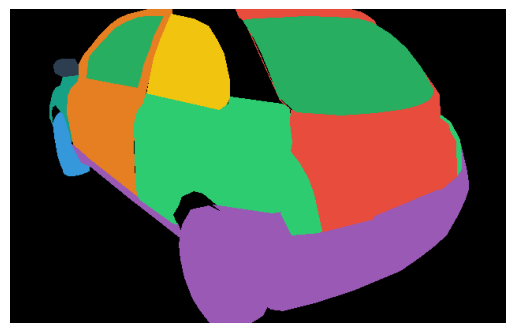

[[  0   0   0]
 [ 22 160 133]
 [ 39 174  96]
 [ 44  62  80]
 [ 46 204 113]
 [ 52 152 219]
 [155  89 182]
 [230 126  34]
 [231  76  60]
 [241 196  15]]
[[ 22 160 133]
 [ 39 174  96]
 [ 44  62  80]
 [ 46 204 113]
 [ 52  73  94]
 [ 52 152 219]
 [142  68 173]
 [155  89 182]
 [230 126  34]
 [231  76  60]
 [241 196  15]
 [243 156  18]]


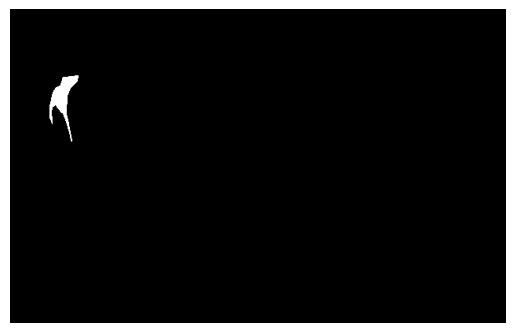

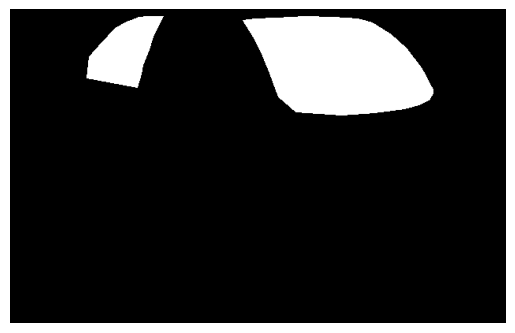

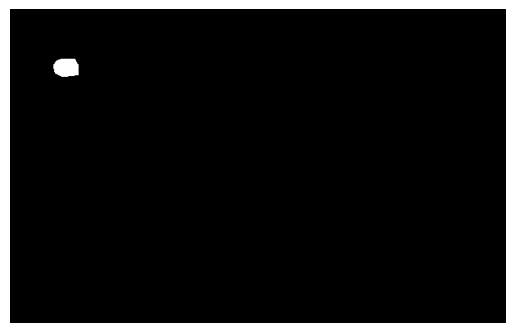

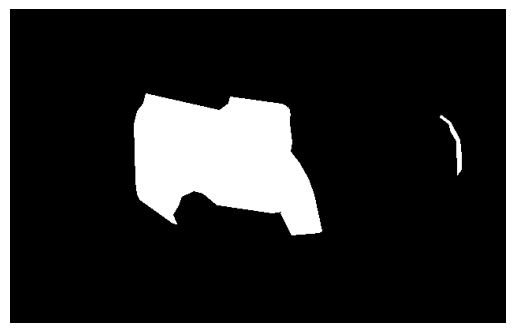

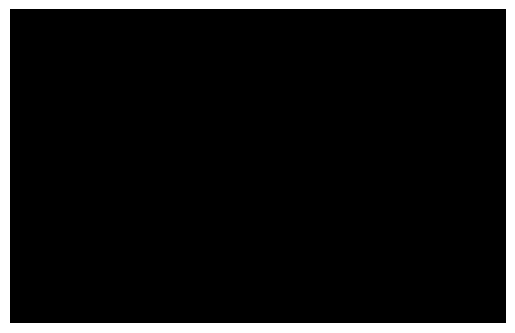

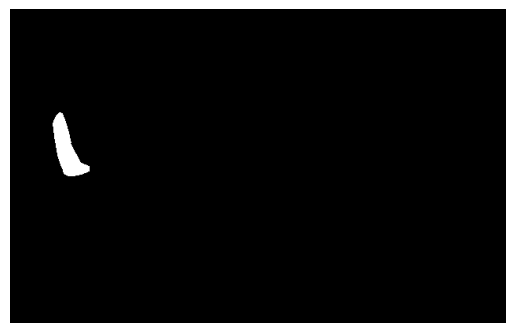

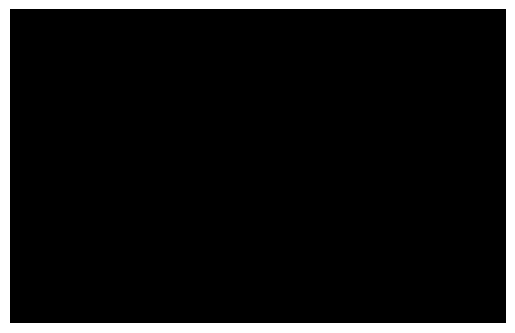

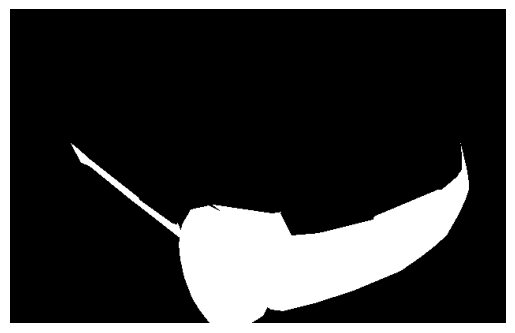

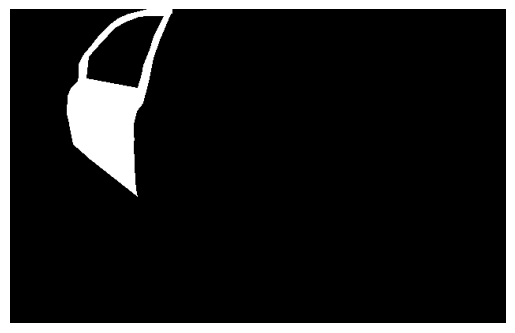

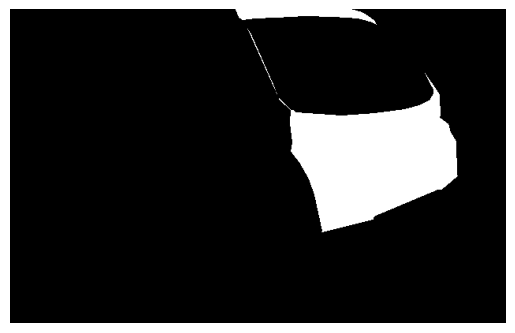

(1, 12, 398, 629)

In [12]:
test_img = image_to_tensor(DATA_PATH)
batch = test_img[None, :]
print(batch.shape)
masks = split_segmentation_masks(batch, classes)

for i in range(10):
    
    display_image(np.transpose(masks, (0, 2, 3, 1))[0, ..., i])
masks.shape

In [13]:
def get_part_mask_path(i):
    

SyntaxError: incomplete input (3757254684.py, line 2)